# Assignment 05 — CNN trên 2 tập ảnh và dữ liệu nguy cơ tiểu đường

**Mục tiêu:** giải thích CNN bằng công thức và code; tìm hiểu các mô hình cải tiến; thực nghiệm trên **MNIST, Fashion-MNIST và Diabetes Risk Prediction (50K patients)** với M1 CNN cơ bản, M2 BatchNorm, M3 Residual, M4 SE Attention. M5–M7 là các CNN ảnh kinh điển phiên bản thu nhỏ.

Notebook tham khảo cấu trúc `A05_06_huydv.381.pdf`, nhưng sử dụng **bộ Diabetes khác**, nên không thể dùng số liệu Diabetes từ bài tham khảo để đối chiếu trực tiếp. Các kết quả sẽ được tính sau khi chạy.

**Chuẩn bị:** cài `pip install torch torchvision numpy pandas scikit-learn matplotlib`. Tải [Diabetes Risk Prediction Dataset (50K patients)](https://www.kaggle.com/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients), giải nén và đặt `diabetes_risk_prediction_dataset.csv` trong thư mục `data/` nằm cùng thư mục đang chạy notebook. Notebook tự tải hai tập ảnh lần đầu nếu có Internet. Đặt `QUICK_MODE=True` để thử pipeline trước khi chạy đầy đủ. Trong Jupyter, `%pwd` cho biết thư mục hiện hành.

**Phạm vi:** đây là dữ liệu **tổng hợp** về mức nguy cơ, không phải kết quả chẩn đoán của người bệnh. Nhãn có ba lớp Low, Moderate, High. Với dữ liệu dạng bảng, Conv1d chỉ dùng để minh họa kiến trúc; thứ tự cột không mang ý nghĩa lân cận tự nhiên.


## 1. CNN là một hàm hợp

Neuron: $z=\mathbf w^\top\mathbf x+b$, $a=\operatorname{ReLU}(z)=\max(0,z)$. Với CNN, phép tích chập học một bộ lọc dùng chung ở nhiều vị trí:

$$Y_{c_o,i,j}=b_{c_o}+\sum_{c_i,u,v}K_{c_o,c_i,u,v}X_{c_i,iS+u-P,jS+v-P}.$$

Trong thư viện deep learning, `Conv2d` thường tính **tương quan chéo** (không lật kernel), dù vẫn được gọi là convolution. Kích thước đầu ra một chiều là $\lfloor(H+2P-D(K-1)-1)/S+1\rfloor$.

CNN có thể viết $f_\theta=C\circ P_2\circ\sigma\circ K_2\circ P_1\circ\sigma\circ K_1$, với $K$ là tích chập, $\sigma$ là kích hoạt, $P$ là pooling, $C$ là bộ phân loại. Khi học, `loss.backward()` tính gradient $\nabla_\theta L$ theo quy tắc dây chuyền; Adam cập nhật tham số. `CrossEntropyLoss` nhận logits đa lớp; `BCEWithLogitsLoss` nhận logits nhị phân (đã tích hợp sigmoid ổn định số học).

In [1]:
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
QUICK_MODE = False  # True: thử pipeline với ít mẫu/epoch; False: cấu hình để nộp
BATCH_IMAGE, BATCH_TABULAR = 64, 256
IMAGE_EPOCHS, DIABETES_EPOCHS = (1, 1) if QUICK_MODE else (5, 5)
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print('Thiết bị:', DEVICE, '| Chạy thử:', QUICK_MODE)


Thiết bị: cpu | Chạy thử: False


### 1.1. Đối chiếu phép lọc thủ công với PyTorch

Ví dụ một kênh, kernel 2×2, stride 1, không padding. Nhờ đó thấy rõ phép nhân từng phần tử rồi cộng, và cách PyTorch tính đạo hàm.

In [2]:
x_np = np.array([[1, 2, 0], [3, 1, 2], [0, 1, 3]], dtype=np.float32)
k_np = np.array([[1, 0], [-1, 2]], dtype=np.float32)
manual = np.array([[np.sum(x_np[i:i+2, j:j+2] * k_np)
                    for j in range(2)] for i in range(2)])
x_t = torch.tensor(x_np)[None, None].requires_grad_()
conv = nn.Conv2d(1, 1, kernel_size=2, bias=False)
with torch.no_grad():
    conv.weight.copy_(torch.tensor(k_np)[None, None])
out = conv(x_t)
assert np.allclose(manual, out.detach().numpy()[0, 0])
out.sum().backward()
print('Tự tính:\n', manual, '\nPyTorch:\n', out.detach().numpy()[0, 0])
print('Gradient theo kernel:\n', conv.weight.grad[0, 0])


Tự tính:
 [[0. 5.]
 [5. 6.]] 
PyTorch:
 [[0. 5.]
 [5. 6.]]
Gradient theo kernel:
 tensor([[7., 5.],
        [5., 7.]])


## 2. Sự phát triển của CNN

| Mô hình / ý tưởng | Đặc điểm | Vấn đề hướng tới |
|---|---|---|
| LeNet | Conv, pooling, dense | Nhận dạng ảnh đầu vào nhỏ |
| AlexNet | Mạng sâu hơn, ReLU, dropout | Tăng năng lực biểu diễn |
| VGG | Xếp nhiều kernel 3×3 | Học đặc trưng sâu theo khối đồng nhất |
| Batch Normalization | Chuẩn hóa activation theo minibatch | Làm quá trình tối ưu ổn định hơn |
| ResNet | Nhánh tắt $y=F(x)+x$ | Hỗ trợ truyền tín hiệu/gradient qua mạng sâu |
| SE Attention | Học trọng số theo kênh | Điều chỉnh mức quan trọng của feature map |

Ở đây **M1 là baseline**, **M2 thêm BatchNorm**, **M3 thêm residual lên M2**, **M4 thêm SE attention lên M3**. Nhờ đó có thể so sánh từng bước cải tiến. Các tên LeNet/AlexNet/VGG trong phần mở rộng là các **phiên bản thu nhỏ, thích nghi ảnh 28×28**, không phải bản gốc.

## 3. Dữ liệu: MNIST, Fashion-MNIST và Diabetes Risk 50K

Hai bộ ảnh xám 28×28 có 10 lớp. Mỗi bộ dành 6.000 ảnh từ train chính thức cho validation, giữ test chính thức. Bộ Diabetes Kaggle gồm dữ liệu bảng **tổng hợp**, với nhãn `Diabetes_Risk` ba mức Low/Moderate/High. Tách train/validation/test có phân tầng. Bộ mã chỉ dùng các chỉ số đầu vào được chỉ định bên dưới; không đưa `Patient_ID`, `Risk_Score`, cột khuyến nghị hay các cột khác có thể là thông tin sinh ra sau khi tính mức nguy cơ vào mô hình. Imputer và scaler chỉ fit trên train.

Vì nhãn Diabetes không phải `Outcome` nhị phân như bộ Pima trong PDF tham khảo, dùng `CrossEntropyLoss`, đầu ra ba logits, và dự đoán bằng `argmax`.


MNIST {'train': 54000, 'val': 6000, 'test': 10000}


100%|██████████| 29.5k/29.5k [00:00<00:00, 144kB/s]


Fashion-MNIST {'train': 54000, 'val': 6000, 'test': 10000}


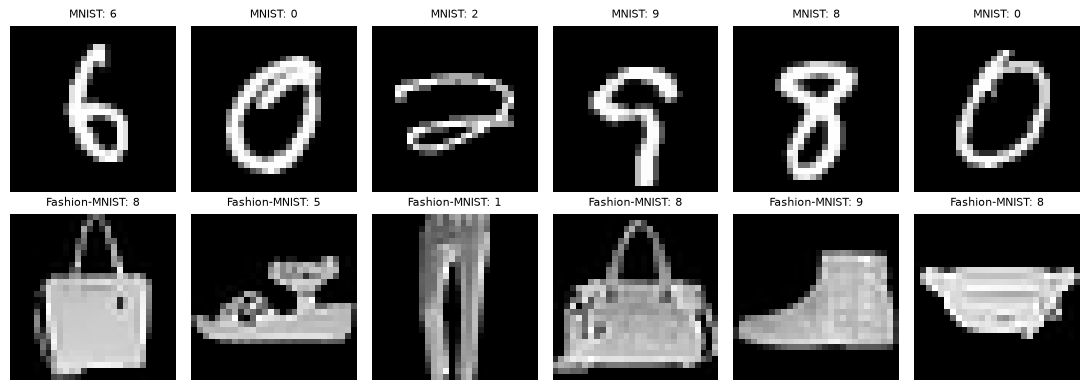

In [3]:
DATA = Path('data')
DATA.mkdir(exist_ok=True)
def image_loaders(dataset_class, name):
    full_train = dataset_class(DATA, train=True, download=True, transform=transforms.ToTensor())
    test_set = dataset_class(DATA, train=False, download=True, transform=transforms.ToTensor())
    train_set, val_set = random_split(full_train, [54000, 6000],
                                      generator=torch.Generator().manual_seed(SEED))
    if QUICK_MODE:
        # Tập test vẫn giữ nguyên; chỉ giảm chi phí train/validation khi kiểm tra pipeline.
        train_set = torch.utils.data.Subset(train_set, range(2048))
        val_set = torch.utils.data.Subset(val_set, range(512))
    loaders = {
        'train': DataLoader(train_set, batch_size=BATCH_IMAGE, shuffle=True, num_workers=0),
        'val': DataLoader(val_set, batch_size=BATCH_IMAGE, shuffle=False, num_workers=0),
        'test': DataLoader(test_set, batch_size=BATCH_IMAGE, shuffle=False, num_workers=0),
    }
    print(name, {k: len(v.dataset) for k, v in loaders.items()})
    return loaders

image_data = {
    'MNIST': image_loaders(datasets.MNIST, 'MNIST'),
    'Fashion-MNIST': image_loaders(datasets.FashionMNIST, 'Fashion-MNIST'),
}
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax_row, (name, loaders) in zip(axes, image_data.items()):
    images, labels = next(iter(loaders['train']))
    for i, ax in enumerate(ax_row):
        ax.imshow(images[i, 0], cmap='gray')
        ax.set_title(f'{name}: {labels[i].item()}', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.show()


In [4]:
# Tải CSV từ Kaggle theo liên kết ở đầu notebook, đặt vào data/.
DIABETES_CSV = DATA / 'diabetes_risk_prediction_dataset.csv'
if not DIABETES_CSV.exists():
    raise FileNotFoundError(
        f'Chưa thấy {DIABETES_CSV.resolve()}. Tải bộ Kaggle 50K, giải nén và '
        'chép diabetes_risk_prediction_dataset.csv vào thư mục data/ cạnh notebook.')
df = pd.read_csv(DIABETES_CSV)
df.columns = df.columns.str.strip()
TARGET = 'Diabetes_Risk'
assert TARGET in df.columns, f'Thiếu cột {TARGET}; các cột hiện có: {df.columns.tolist()}'
LABELS = ['Low', 'Moderate', 'High']
target_text = df[TARGET].astype('string').str.strip().str.title()
assert target_text.notna().all(), 'Diabetes_Risk chứa nhãn rỗng'
assert set(target_text.unique()) == set(LABELS), f'Nhãn ngoài dự kiến: {target_text.unique().tolist()}'

# Chỉ lấy các phép đo đã xuất hiện trong mô tả CSV; tránh ID, cột điểm rủi ro,
# dự đoán/khuyến nghị và những cột có nguy cơ tiết lộ trực tiếp nhãn.
candidate_features = ['Age', 'Height_cm', 'Weight_kg', 'BMI',
                      'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c']
FEATURES = [name for name in candidate_features if name in df.columns]
if len(FEATURES) < 3:
    raise ValueError(f'CSV cần ít nhất 3 cột trong {candidate_features}. '
                     f'Các cột hiện có: {df.columns.tolist()}')
print('Kích thước dữ liệu:', df.shape, '\nĐặc trưng:', FEATURES)
print('Phân bố nhãn:\n', target_text.value_counts())
display(df[FEATURES + [TARGET]].head())


Kích thước dữ liệu: (50000, 41) 
Đặc trưng: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c']
Phân bố nhãn:
 Diabetes_Risk
High        36593
Moderate    12937
Low           470
Name: count, dtype: Int64


,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Diabetes_Risk
0,32.0,182.1,65.8,19.8,71.2,88.4,10.4,Moderate
1,42.0,148.5,101.2,45.9,121.8,247.3,11.3,High
2,89.0,158.1,NaN,37.9,131.8,141.9,6.3,High
3,87.0,190.9,95.9,26.3,99.1,90.1,7.4,High
4,27.0,156.9,101.9,41.4,77.1,93.8,12.0,High


In [5]:
X = df[FEATURES].apply(pd.to_numeric, errors='coerce').copy()
y = target_text.map({label: i for i, label in enumerate(LABELS)}).to_numpy(dtype=np.int64)
idx = np.arange(len(y))
trainval_idx, test_idx = train_test_split(idx, test_size=0.15, stratify=y, random_state=SEED)
train_idx, val_idx = train_test_split(trainval_idx, test_size=0.15/0.85,
                                     stratify=y[trainval_idx], random_state=SEED)
imputer = SimpleImputer(strategy='median').fit(X.iloc[train_idx])
scaler = StandardScaler().fit(imputer.transform(X.iloc[train_idx]))

def make_tabular_loader(indices, shuffle=False):
    values = scaler.transform(imputer.transform(X.iloc[indices])).astype(np.float32)
    tensor_x = torch.from_numpy(values).unsqueeze(1)  # [N, 1, số đặc trưng]
    tensor_y = torch.from_numpy(y[indices]).long()
    return DataLoader(TensorDataset(tensor_x, tensor_y), batch_size=BATCH_TABULAR,
                      shuffle=shuffle, num_workers=0)

# Chạy thử giảm mẫu huấn luyện nhưng giữ stratify, tập test đầy đủ.
if QUICK_MODE:
    _, train_idx = train_test_split(train_idx, test_size=2048,
                                   stratify=y[train_idx], random_state=SEED)
    _, val_idx = train_test_split(val_idx, test_size=512,
                                 stratify=y[val_idx], random_state=SEED)
diabetes_data = {'train': make_tabular_loader(train_idx, True),
                 'val': make_tabular_loader(val_idx),
                 'test': make_tabular_loader(test_idx)}
print('Diabetes 50K:', {k: len(v.dataset) for k, v in diabetes_data.items()})
assert set(train_idx).isdisjoint(val_idx) and set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)


Diabetes 50K: {'train': 34999, 'val': 7501, 'test': 7500}


## 4. Kiến trúc 2D: M1 → M4

Tất cả đầu vào ảnh có dạng `[batch, 1, 28, 28]`; đầu ra là `[batch, 10]`. M3 dùng residual block sau tầng đầu với 16 kênh; M4 thêm SE sau block đó. Hàm `AdaptiveAvgPool2d((7,7))` giữ kích thước cuối ổn định.

In [6]:
class Residual2D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels))
    def forward(self, x):
        return torch.relu(x + self.net(x))

class SE2D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.gate = nn.Sequential(nn.Flatten(), nn.Linear(channels, channels // reduction),
                                  nn.ReLU(), nn.Linear(channels // reduction, channels), nn.Sigmoid())
    def forward(self, x):
        return x * self.gate(self.pool(x)).view(x.size(0), x.size(1), 1, 1)

class ImageCNN(nn.Module):
    def __init__(self, variant='M1'):
        super().__init__()
        assert variant in ('M1', 'M2', 'M3', 'M4')
        norm = variant != 'M1'
        self.stem = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1),
                                  nn.BatchNorm2d(16) if norm else nn.Identity(), nn.ReLU())
        self.residual = Residual2D(16) if variant in ('M3', 'M4') else nn.Identity()
        self.attention = SE2D(16) if variant == 'M4' else nn.Identity()
        self.head = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(16, 32, 3, padding=1),
                                  nn.BatchNorm2d(32) if norm else nn.Identity(), nn.ReLU(),
                                  nn.MaxPool2d(2), nn.AdaptiveAvgPool2d((7, 7)), nn.Flatten(),
                                  nn.Linear(32 * 7 * 7, 10))
    def forward(self, x):
        x = self.stem(x)
        x = self.attention(self.residual(x))
        return self.head(x)


### 4.1. Ba mô hình kinh điển thu nhỏ cho ảnh 28×28

M5 (LeNet style), M6 (AlexNet style), M7 (VGG style) là phần mở rộng để quan sát lịch sử kiến trúc. Chúng được thu nhỏ theo ảnh và tài nguyên học tập, nên không thể so sánh trực tiếp với bản gốc.

In [7]:
class LeNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(1, 6, 5), nn.Tanh(), nn.AvgPool2d(2),
                                 nn.Conv2d(6, 16, 5), nn.Tanh(), nn.AvgPool2d(2),
                                 nn.Flatten(), nn.Linear(16 * 4 * 4, 120), nn.Tanh(),
                                 nn.Linear(120, 84), nn.Tanh(), nn.Linear(84, 10))
    def forward(self, x): return self.net(x)

class AlexNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(1, 32, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
                                 nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                 nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
                                 nn.AdaptiveAvgPool2d((3, 3)), nn.Flatten(),
                                 nn.Linear(128 * 3 * 3, 256), nn.ReLU(), nn.Dropout(0.3),
                                 nn.Linear(256, 10))
    def forward(self, x): return self.net(x)

class VGGSmall(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        c = 1
        for channels in (32, 64, 128):
            layers += [nn.Conv2d(c, channels, 3, padding=1), nn.ReLU(),
                       nn.Conv2d(channels, channels, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)]
            c = channels
        self.net = nn.Sequential(*layers, nn.AdaptiveAvgPool2d((3, 3)), nn.Flatten(),
                                 nn.Linear(128 * 3 * 3, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

image_models = {**{f'M{i}': (lambda i=i: ImageCNN(f'M{i}')) for i in range(1, 5)},
                'M5 LeNet': LeNetSmall, 'M6 AlexNet': AlexNetSmall, 'M7 VGG': VGGSmall}


## 5. CNN 1D cho Diabetes Risk (ba lớp)

Mỗi hàng thành `[batch, 1, số đặc trưng]`. Bốn biến thể M1–M4 vẫn gồm CNN cơ bản, thêm BN, residual và SE. Bộ phân loại trả về **ba logits** tương ứng Low, Moderate, High. Do dùng dữ liệu Kaggle 50K thay vì Pima, số tham số, nhãn và độ chính xác trong PDF tham khảo không áp dụng cho phần này.


In [8]:
class Residual1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(channels, channels, 3, padding=1),
                                 nn.BatchNorm1d(channels), nn.ReLU(),
                                 nn.Conv1d(channels, channels, 3, padding=1),
                                 nn.BatchNorm1d(channels))
    def forward(self, x): return torch.relu(x + self.net(x))

class SE1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.gate = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(channels, channels // reduction), nn.ReLU(),
                                  nn.Linear(channels // reduction, channels), nn.Sigmoid())
    def forward(self, x): return x * self.gate(x).unsqueeze(-1)

class DiabetesCNN(nn.Module):
    def __init__(self, variant='M1'):
        super().__init__()
        assert variant in ('M1', 'M2', 'M3', 'M4')
        norm = variant != 'M1'
        self.stem = nn.Sequential(nn.Conv1d(1, 16, 3, padding=1),
                                  nn.BatchNorm1d(16) if norm else nn.Identity(), nn.ReLU())
        self.residual = Residual1D(16) if variant in ('M3', 'M4') else nn.Identity()
        self.attention = SE1D(16) if variant == 'M4' else nn.Identity()
        self.head = nn.Sequential(nn.MaxPool1d(2), nn.Conv1d(16, 32, 3, padding=1),
                                  nn.BatchNorm1d(32) if norm else nn.Identity(), nn.ReLU(),
                                  nn.AdaptiveAvgPool1d(4), nn.Flatten(), nn.Linear(32 * 4, 3))
    def forward(self, x):
        x = self.attention(self.residual(self.stem(x)))
        return self.head(x)

tabular_models = {f'M{i}': (lambda i=i: DiabetesCNN(f'M{i}')) for i in range(1, 5)}
def count_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, builder in image_models.items():
    model = builder().eval()
    with torch.no_grad(): assert model(torch.randn(4, 1, 28, 28)).shape == (4, 10)
    print('Ảnh', name, count_params(model))
for name, builder in tabular_models.items():
    model = builder().eval()
    with torch.no_grad(): assert model(torch.randn(4, 1, len(FEATURES))).shape == (4, 3)
    print('Bảng', name, count_params(model))


Ảnh M1 20490
Ảnh M2 20586
Ảnh M3 25290
Ảnh M4 25438
Ảnh M5 LeNet 44426
Ảnh M6 AlexNet 390922
Ảnh M7 VGG 435306
Bảng M1 2019
Bảng M2 2115
Bảng M3 3747
Bảng M4 3895


## 6. Huấn luyện và đánh giá

Mỗi mô hình khởi tạo mới. Chọn checkpoint theo validation loss; dùng test một lần sau khi học. Cả ba bộ đều phân loại đa lớp bằng `CrossEntropyLoss` và `argmax`. Báo cáo thêm precision, recall, F1 weighted vì bộ Diabetes 50K có thể mất cân bằng lớp. Thời gian huấn luyện phụ thuộc thiết bị.


In [9]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, targets, predictions = 0.0, [], []
    with torch.set_grad_enabled(training):
        for inputs, y_true in loader:
            inputs, y_true = inputs.to(DEVICE), y_true.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, y_true.long())
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_true)
            preds = logits.argmax(dim=1)
            targets.extend(y_true.long().cpu().tolist())
            predictions.extend(preds.cpu().tolist())
    return total_loss / len(loader.dataset), accuracy_score(targets, predictions), targets, predictions

def fit_and_test(builder, loaders, epochs):
    model = builder().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_loss, best_state, best_epoch = float('inf'), None, -1
    start = time.perf_counter()
    for epoch in range(epochs):
        tr_loss, tr_acc, _, _ = run_epoch(model, loaders['train'], criterion, optimizer)
        va_loss, va_acc, _, _ = run_epoch(model, loaders['val'], criterion)
        for key, val in [('train_loss', tr_loss), ('val_loss', va_loss),
                         ('train_acc', tr_acc), ('val_acc', va_acc)]: history[key].append(val)
        if va_loss < best_loss:
            best_loss, best_state, best_epoch = va_loss, copy.deepcopy(model.state_dict()), epoch + 1
        print(f'  epoch {epoch + 1}/{epochs} | train {tr_loss:.4f}/{tr_acc:.3f}'
              f' | val {va_loss:.4f}/{va_acc:.3f}')
    elapsed = time.perf_counter() - start
    model.load_state_dict(best_state)
    test_loss, test_acc, y_true, y_pred = run_epoch(model, loaders['test'], criterion)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted',
                                                  zero_division=0)
    stats = {'best_epoch': best_epoch, 'test_loss': test_loss, 'accuracy': test_acc,
             'precision': p, 'recall': r, 'f1': f1, 'parameters': count_params(model),
             'train_seconds': elapsed}
    return stats, history, (y_true, y_pred)


In [10]:
results, histories, predictions = [], {}, {}
experiments = [(dataset, name, builder, loaders, IMAGE_EPOCHS)
               for dataset, loaders in image_data.items()
               for name, builder in image_models.items()]
experiments += [('Diabetes', name, builder, diabetes_data, DIABETES_EPOCHS)
                for name, builder in tabular_models.items()]
for dataset, name, builder, loaders, epochs in experiments:
    print(f'\n{dataset} | {name}')
    stats, history, pred = fit_and_test(builder, loaders, epochs)
    results.append({'dataset': dataset, 'model': name, **stats})
    histories[(dataset, name)] = history
    predictions[(dataset, name)] = pred
results_df = pd.DataFrame(results)
display(results_df.round(4))



MNIST | M1
  epoch 1/5 | train 0.2716/0.920 | val 0.0942/0.972
  epoch 2/5 | train 0.0756/0.977 | val 0.0697/0.980
  epoch 3/5 | train 0.0538/0.983 | val 0.0520/0.984
  epoch 4/5 | train 0.0439/0.987 | val 0.0497/0.984
  epoch 5/5 | train 0.0371/0.988 | val 0.0509/0.986

MNIST | M2
  epoch 1/5 | train 0.1382/0.959 | val 0.0737/0.979
  epoch 2/5 | train 0.0529/0.983 | val 0.0564/0.984
  epoch 3/5 | train 0.0403/0.987 | val 0.0447/0.986
  epoch 4/5 | train 0.0333/0.989 | val 0.0537/0.984
  epoch 5/5 | train 0.0273/0.991 | val 0.0533/0.986

MNIST | M3
  epoch 1/5 | train 0.1199/0.965 | val 0.0781/0.975
  epoch 2/5 | train 0.0460/0.986 | val 0.0538/0.985
  epoch 3/5 | train 0.0351/0.989 | val 0.0392/0.988
  epoch 4/5 | train 0.0276/0.991 | val 0.0461/0.987
  epoch 5/5 | train 0.0234/0.992 | val 0.0361/0.989

MNIST | M4
  epoch 1/5 | train 0.1183/0.965 | val 0.0611/0.982
  epoch 2/5 | train 0.0479/0.985 | val 0.0843/0.974
  epoch 3/5 | train 0.0351/0.989 | val 0.0482/0.985
  epoch 4/5 | tr

,dataset,model,best_epoch,test_loss,accuracy,precision,recall,f1,parameters,train_seconds
0,MNIST,M1,4,0.0396,0.9868,0.9869,0.9868,0.9868,20490,108.2295
1,MNIST,M2,3,0.0361,0.9879,0.9880,0.9879,0.9879,20586,141.1036
2,MNIST,M3,5,0.0271,0.9915,0.9915,0.9915,0.9915,25290,262.7758
3,MNIST,M4,5,0.0276,0.9909,0.9909,0.9909,0.9909,25438,296.7519
4,MNIST,M5 LeNet,5,0.0527,0.9837,0.9838,0.9837,0.9837,44426,75.8373
5,MNIST,M6 AlexNet,5,0.0282,0.9904,0.9905,0.9904,0.9904,390922,277.5744
6,MNIST,M7 VGG,5,0.0325,0.9917,0.9917,0.9917,0.9917,435306,586.0539
7,Fashion-MNIST,M1,5,0.3031,0.8951,0.8970,0.8951,0.8949,20490,119.7108
8,Fashion-MNIST,M2,3,0.2761,0.9022,0.9050,0.9022,0.9030,20586,147.8043
9,Fashion-MNIST,M3,5,0.2408,0.9162,0.9151,0.9162,0.9151,25290,264.2814


## 7. Biểu đồ và phân tích kết quả

Đọc bảng theo **từng dataset**: so sánh M1–M4 về mức tăng accuracy, F1, số tham số và thời gian; với ảnh còn so sánh M5–M7. Xem train/val loss để phát hiện lệch giữa hai tập. Confusion matrix cho biết nhóm nhãn dễ nhầm. Chênh lệch nhỏ trên một lần chia dữ liệu không đủ để khẳng định kiến trúc nào luôn tốt hơn.


 MNIST


,model,accuracy,precision,recall,f1,test_loss,delta_vs_M1_pp,parameters,train_seconds
0,M1,0.987,0.987,0.987,0.987,0.040,0.00,20490,108.229
1,M2,0.988,0.988,0.988,0.988,0.036,0.11,20586,141.104
2,M3,0.992,0.992,0.992,0.991,0.027,0.47,25290,262.776
3,M4,0.991,0.991,0.991,0.991,0.028,0.41,25438,296.752
4,M5 LeNet,0.984,0.984,0.984,0.984,0.053,-0.31,44426,75.837
5,M6 AlexNet,0.990,0.991,0.990,0.990,0.028,0.36,390922,277.574
6,M7 VGG,0.992,0.992,0.992,0.992,0.032,0.49,435306,586.054


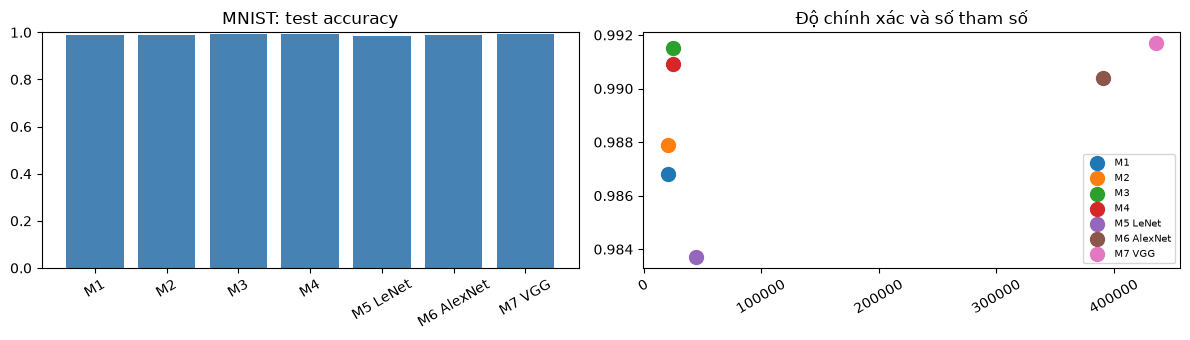


 Fashion-MNIST


,model,accuracy,precision,recall,f1,test_loss,delta_vs_M1_pp,parameters,train_seconds
7,M1,0.895,0.897,0.895,0.895,0.303,0.00,20490,119.711
8,M2,0.902,0.905,0.902,0.903,0.276,0.71,20586,147.804
9,M3,0.916,0.915,0.916,0.915,0.241,2.11,25290,264.281
10,M4,0.917,0.917,0.917,0.915,0.242,2.21,25438,262.797
11,M5 LeNet,0.860,0.863,0.860,0.859,0.381,-3.52,44426,77.122
12,M6 AlexNet,0.889,0.889,0.889,0.887,0.310,-0.61,390922,273.865
13,M7 VGG,0.907,0.907,0.907,0.906,0.256,1.16,435306,622.572


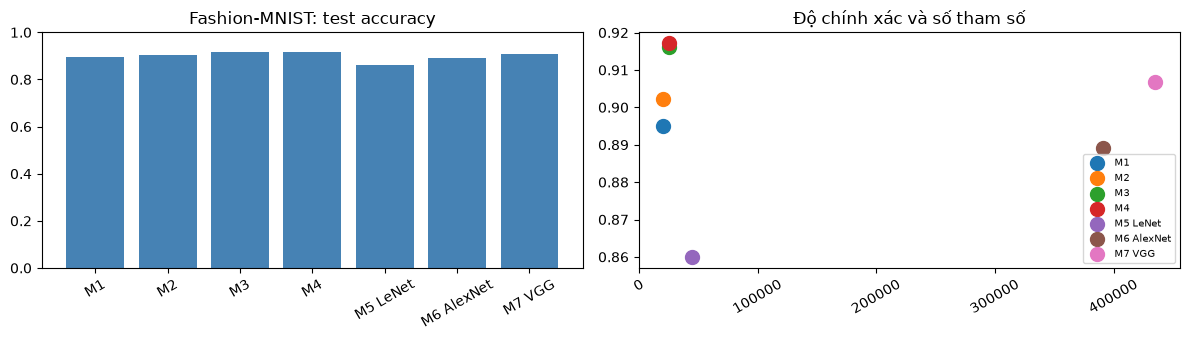


 Diabetes


,model,accuracy,precision,recall,f1,test_loss,delta_vs_M1_pp,parameters,train_seconds
14,M1,0.756,0.721,0.756,0.723,0.540,0.000,2019,7.345
15,M2,0.757,0.724,0.757,0.728,0.532,0.093,2115,7.278
16,M3,0.761,0.727,0.761,0.725,0.532,0.427,3747,8.938
17,M4,0.761,0.727,0.761,0.725,0.527,0.453,3895,10.975


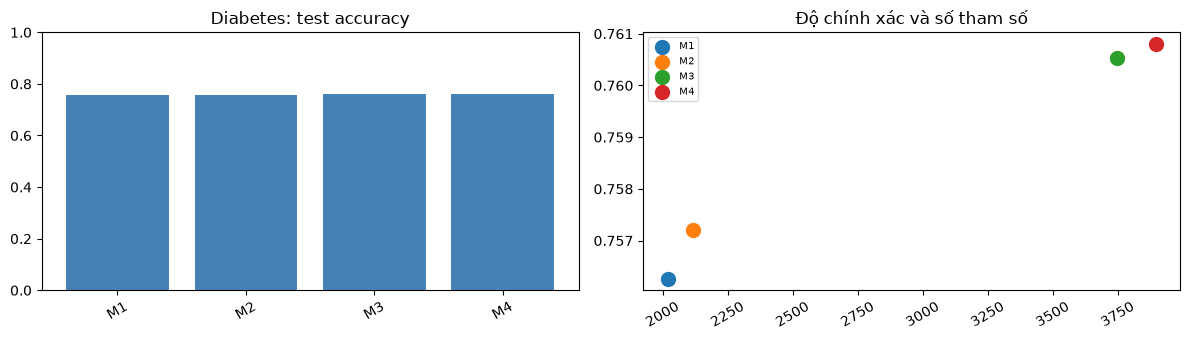

In [11]:
for dataset, group in results_df.groupby('dataset', sort=False):
    baseline = group.loc[group['model'] == 'M1', 'accuracy'].iloc[0]
    table = group.copy()
    table['delta_vs_M1_pp'] = 100 * (table['accuracy'] - baseline)
    print('\n', dataset)
    display(table[['model', 'accuracy', 'precision', 'recall', 'f1',
                   'test_loss', 'delta_vs_M1_pp', 'parameters', 'train_seconds']].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].bar(group['model'], group['accuracy'], color='steelblue')
    axes[0].set_ylim(0, 1)
    axes[0].set_title(f'{dataset}: test accuracy')
    for row in group.itertuples():
        axes[1].scatter(row.parameters, row.accuracy, s=100, label=row.model)
    axes[1].set_title('Độ chính xác và số tham số')
    axes[1].legend(fontsize=7)
    for ax in axes: ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


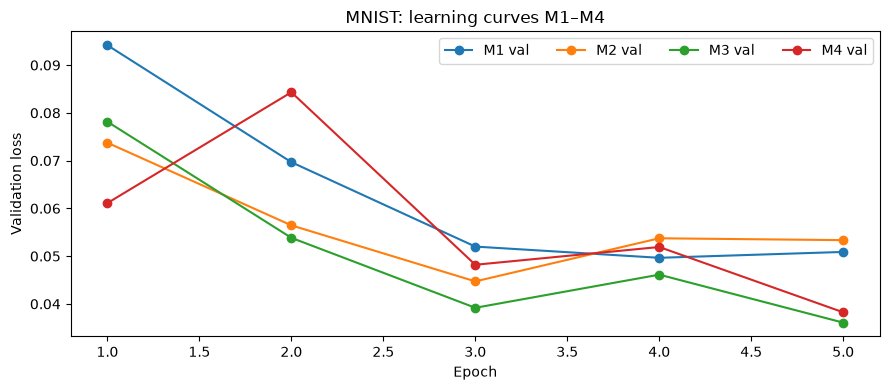

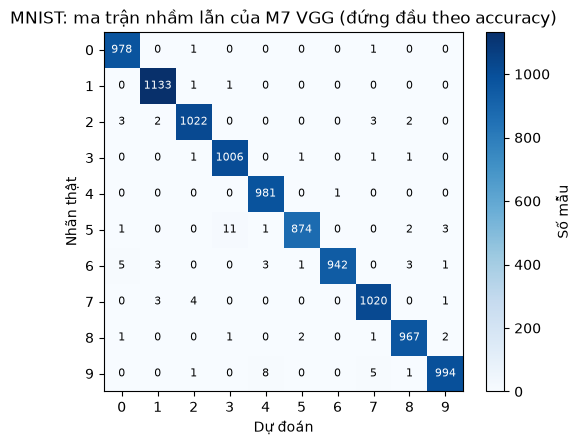

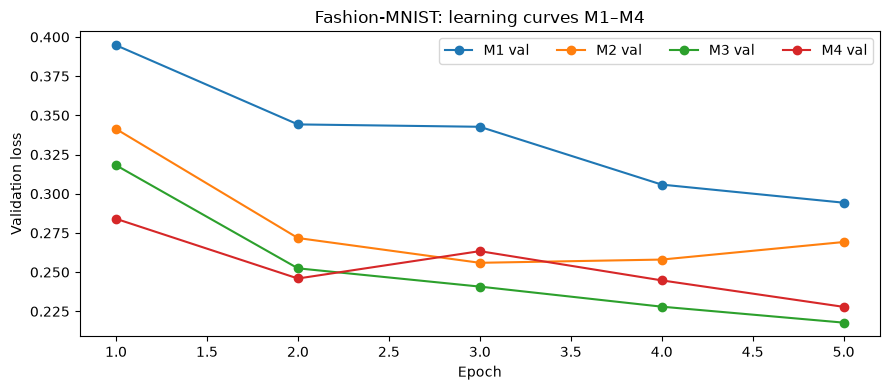

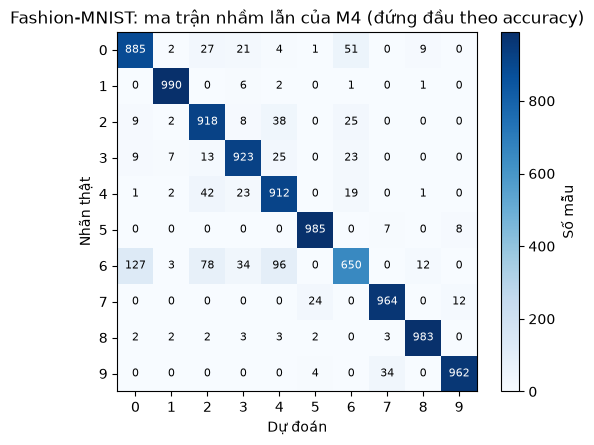

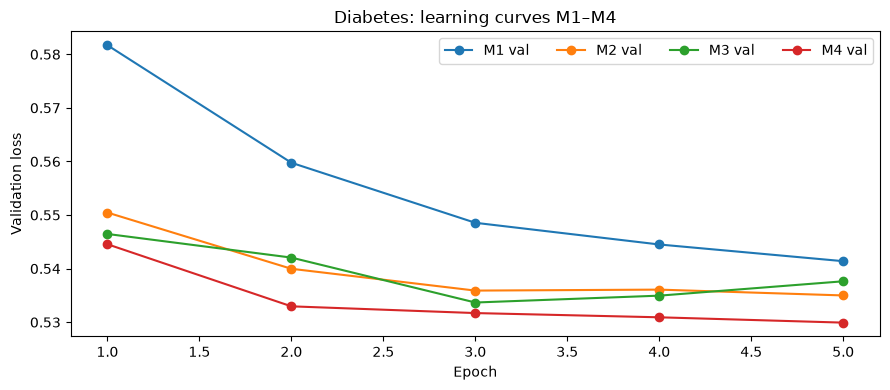

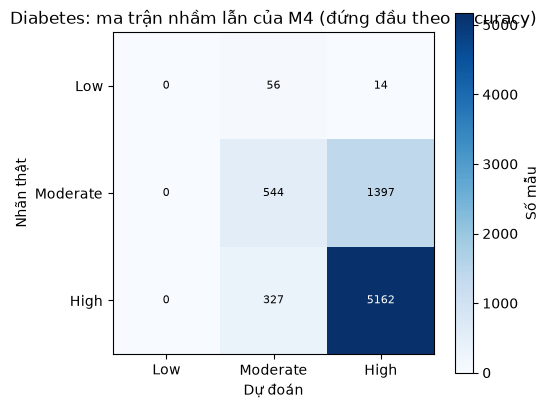

In [12]:
for dataset in ('MNIST', 'Fashion-MNIST', 'Diabetes'):
    fig, ax = plt.subplots(figsize=(9, 4))
    for name in ('M1', 'M2', 'M3', 'M4'):
        h = histories[(dataset, name)]
        ax.plot(range(1, len(h['val_loss']) + 1), h['val_loss'], marker='o', label=f'{name} val')
    ax.set(xlabel='Epoch', ylabel='Validation loss', title=f'{dataset}: learning curves M1–M4')
    ax.legend(ncol=4)
    plt.tight_layout()
    plt.show()

    winner = results_df.loc[results_df['dataset'] == dataset].sort_values('accuracy', ascending=False).iloc[0]
    name = winner['model']
    y_true, y_pred = predictions[(dataset, name)]
    labels = list(range(3)) if dataset == 'Diabetes' else list(range(10))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5.5, 4.5))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar(label='Số mẫu')
    plt.xticks(range(len(labels)), LABELS if dataset == 'Diabetes' else labels)
    plt.yticks(range(len(labels)), LABELS if dataset == 'Diabetes' else labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
    plt.title(f'{dataset}: ma trận nhầm lẫn của {name} (đứng đầu theo accuracy)')
    plt.xlabel('Dự đoán'); plt.ylabel('Nhãn thật')
    plt.tight_layout()
    plt.show()


## 8. Gợi ý nhận xét sau khi chạy

1. So sánh M1–M4 trong từng dataset bằng accuracy và F1; xem cả precision/recall từng lớp nếu muốn đánh giá lớp Low hiếm.
2. Quan sát train/validation loss và ma trận nhầm lẫn 3×3 của Diabetes Risk. Accuracy cao trên dữ liệu tổng hợp có thể phản ánh cách nhãn được sinh từ các phép đo, **không chứng minh năng lực chẩn đoán lâm sàng**.
3. Nêu trade-off với số tham số và thời gian. Không dùng con số Pima từ PDF tham khảo cho bộ 50K này.
4. Giới hạn: ba mức nguy cơ mất cân bằng; dữ liệu nhân tạo; thứ tự các cột không mang nghĩa không gian; 5 epoch chưa chắc hội tụ. Có thể đối chuẩn Logistic Regression/Random Forest trên cùng split trong bài mở rộng.

**Nguồn:** ảnh đề bài và `A05_06_huydv.381.pdf` do người dùng cung cấp; [Diabetes Risk Prediction Dataset (50K patients)](https://www.kaggle.com/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients); MNIST và Fashion-MNIST qua `torchvision.datasets`.
